# Bank Account Activity and Customer Retention Analysis

## 1. Business Understanding

### Business Problem

A bank wants to better understand patterns associated with active,
dormant, and closed customer accounts.

The objective of this analysis is to examine account characteristics,
including account type, balance, branch, account tenure, and opening
date, to identify patterns associated with account status.

The analysis will focus on evidence from the available data rather
than assuming that any particular factor causes account closure.

### Analytical Objectives

- Examine the distribution of account status.
- Compare account status across account types.
- Analyze account balances by account status.
- Examine account tenure across account-status groups.
- Investigate differences across branches.
- Examine account opening trends over time.
- Analyze account-level and customer-level patterns.
- Identify statistically meaningful relationships.
- Develop evidence-based findings and recommendations.

### Key Questions

1. What proportion of accounts are active, dormant, or closed?
2. How does account status vary across account types?
3. How do account balances differ by account status?
4. Does account tenure differ between account-status groups?
5. Are there differences in account status across branches?
6. Are there periods with unusually high account closures?
7. What patterns should the bank investigate further?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

## 2. Data Loading

In [4]:
df = pd.read_csv('accounts.csv')

## 3. checking to see whether the data is loaded correctly

In [5]:
df.head()

,account_id,customer_id,branch_id,account_type,balance,open_date,status
0,1,11749,141,Current,"95,902.00",2019-10-20,Active
1,2,47716,43,Current,"13,261.61",2026-02-03,Active
2,3,56143,90,Savings,"26,495.92",2020-10-19,Active
3,4,29193,113,Salary,"74,682.72",2012-02-22,Active
4,5,49907,28,Current,"40,419.01",2007-01-03,Active


In [7]:
df.shape

(95000, 7)

In [10]:
df.columns

Index(['account_id', 'customer_id', 'branch_id', 'account_type', 'balance',
       'open_date', 'status'],
      dtype='str')

## 4. Initial Data Inspection

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   account_id    95000 non-null  int64  
 1   customer_id   95000 non-null  int64  
 2   branch_id     95000 non-null  int64  
 3   account_type  95000 non-null  str    
 4   balance       95000 non-null  float64
 5   open_date     95000 non-null  str    
 6   status        95000 non-null  str    
dtypes: float64(1), int64(3), str(3)
memory usage: 7.2 MB


In [12]:
df.describe()

,account_id,customer_id,branch_id,balance
count,"95,000.00","95,000.00","95,000.00","95,000.00"
mean,"47,500.50","29,991.21",75.45,"45,761.24"
std,"27,424.28","17,264.58",43.30,"45,306.41"
min,1.00,1.00,1.00,500.36
25%,"23,750.75","15,114.75",38.00,"13,551.05"
50%,"47,500.50","30,000.00",75.00,"31,768.65"
75%,"71,250.25","44,910.00",113.00,"63,337.51"
max,"95,000.00","60,000.00",150.00,"539,198.59"


In [13]:
df.describe(include="all")

,account_id,customer_id,branch_id,account_type,balance,open_date,status
count,"95,000.00","95,000.00","95,000.00",95000,"95,000.00",95000,95000
unique,NaN,NaN,NaN,5,NaN,7821,3
top,NaN,NaN,NaN,Savings,NaN,2013-07-18,Active
freq,NaN,NaN,NaN,47557,NaN,26,80707
mean,"47,500.50","29,991.21",75.45,NaN,"45,761.24",NaN,NaN
std,"27,424.28","17,264.58",43.30,NaN,"45,306.41",NaN,NaN
min,1.00,1.00,1.00,NaN,500.36,NaN,NaN
25%,"23,750.75","15,114.75",38.00,NaN,"13,551.05",NaN,NaN
50%,"47,500.50","30,000.00",75.00,NaN,"31,768.65",NaN,NaN
75%,"71,250.25","44,910.00",113.00,NaN,"63,337.51",NaN,NaN


In [18]:
df.describe(exclude=["number"]) 

,account_type,open_date,status
count,95000,95000,95000
unique,5,7821,3
top,Savings,2013-07-18,Active
freq,47557,26,80707


In [20]:
df.isna().sum() 

account_id      0
customer_id     0
branch_id       0
account_type    0
balance         0
open_date       0
status          0
dtype: int64

In [21]:
df.duplicated().sum() 

np.int64(0)

## 5. I want to have more insight into the data by asking a series of analytic questions.
**What is the dataset size?**

In [22]:
df.shape

(95000, 7)

**What variables do we have?**

In [23]:
df.columns.tolist()

['account_id',
 'customer_id',
 'branch_id',
 'account_type',
 'balance',
 'open_date',
 'status']

**What are the accounts status?**

In [24]:
df["status"].value_counts()

status
Active     80707
Dormant     9526
Closed      4767
Name: count, dtype: int64

**What account types exist?**

In [25]:
df["account_type"].value_counts()

account_type
Savings          47557
Current          19021
Salary           14270
Fixed Deposit     9458
NRI               4694
Name: count, dtype: int64

**How many branches?**

In [27]:
df['branch_id'].nunique()

150

**How many customers?**

In [28]:
df["customer_id"].nunique()

47640

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("accounts.csv")

df.head()
df.shape
df.columns
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   account_id    95000 non-null  int64  
 1   customer_id   95000 non-null  int64  
 2   branch_id     95000 non-null  int64  
 3   account_type  95000 non-null  str    
 4   balance       95000 non-null  float64
 5   open_date     95000 non-null  str    
 6   status        95000 non-null  str    
dtypes: float64(1), int64(3), str(3)
memory usage: 7.2 MB


In [30]:
df["status"].value_counts(normalize=True).mul(100).round(2)

status
Active    84.95
Dormant   10.03
Closed     5.02
Name: proportion, dtype: float64

Active accounts represent 84.95% of all accounts, while 15.05% are either dormant or closed.

**Checking for missing values**

In [31]:
df.isnull().sum() 

account_id      0
customer_id     0
branch_id       0
account_type    0
balance         0
open_date       0
status          0
dtype: int64

In [34]:
(df.isnull().mean() * 100).round(3)

account_id     0.00
customer_id    0.00
branch_id      0.00
account_type   0.00
balance        0.00
open_date      0.00
status         0.00
dtype: float64

**Checking for duplicate rows**

In [35]:
df.duplicated().sum() 

np.int64(0)

In [36]:
df["customer_id"].nunique() 

47640

In [37]:
df["customer_id"].unique() 

array([11749, 47716, 56143, ...,  8327, 20309, 50149], shape=(47640,))

In [38]:
df["account_id"].duplicated().sum() 

np.int64(0)

In [40]:
df["account_type"].value_counts()

account_type
Savings          47557
Current          19021
Salary           14270
Fixed Deposit     9458
NRI               4694
Name: count, dtype: int64

In [41]:
df["status"].value_counts(normalize=True).mul(100).round(2)

status
Active    84.95
Dormant   10.03
Closed     5.02
Name: proportion, dtype: float64

In [42]:
df["account_type"].unique() 

<ArrowStringArray>
['Current', 'Savings', 'Salary', 'Fixed Deposit', 'NRI']
Length: 5, dtype: str

In [43]:
df["account_type"].nunique() 

5

**Investigating the account balance**

In [44]:
df["balance"].describe() 

count    95,000.00
mean     45,761.24
std      45,306.41
min         500.36
25%      13,551.05
50%      31,768.65
75%      63,337.51
max     539,198.59
Name: balance, dtype: float64

In [45]:
(df["balance"] <= 0).sum() 

np.int64(0)

In [46]:
(df["balance"] < 0).sum() 

np.int64(0)

In [47]:
df["open_date"].nunique() 

7821

In [48]:
df["open_date"].unique()

<ArrowStringArray>
['2019-10-20', '2026-02-03', '2020-10-19', '2012-02-22', '2007-01-03',
 '2022-07-15', '2023-10-12', '2008-04-08', '2008-12-22', '2021-10-01',
 ...
 '2025-03-18', '2010-03-21', '2011-01-30', '2016-04-14', '2005-08-02',
 '2024-03-24', '2022-05-01', '2012-04-06', '2024-06-21', '2017-12-29']
Length: 7821, dtype: str

In [49]:
df["open_date"].min() 

'2005-01-01'

In [50]:
df["open_date"].max() 

'2026-05-31'

## 4. Data Quality Assessment

The dataset was assessed for missing values, duplicate records,
unique identifiers, categorical consistency, numerical values,
and date formatting before performing exploratory analysis.

In [51]:
quality_summary = pd.DataFrame({
    "column": df.columns,
    "missing_values": df.isnull().sum().values,
    "missing_percentage": (df.isnull().mean().values * 100).round(2),
    "data_type": df.dtypes.astype(str).values,
    "unique_values": df.nunique().values
})

quality_summary

,column,missing_values,missing_percentage,data_type,unique_values
0,account_id,0,0.00,int64,95000
1,customer_id,0,0.00,int64,47640
2,branch_id,0,0.00,int64,150
3,account_type,0,0.00,str,5
4,balance,0,0.00,float64,94538
5,open_date,0,0.00,str,7821
6,status,0,0.00,str,3


In [52]:
df["status"].value_counts()
df["status"].value_counts(normalize=True).mul(100).round(2) 

status
Active    84.95
Dormant   10.03
Closed     5.02
Name: proportion, dtype: float64

In [53]:
df["open_date"].head(10) 

0    2019-10-20
1    2026-02-03
2    2020-10-19
3    2012-02-22
4    2007-01-03
5    2022-07-15
6    2023-10-12
7    2008-04-08
8    2008-12-22
9    2021-10-01
Name: open_date, dtype: str

In [54]:
df.duplicated().sum()
df["account_id"].duplicated().sum() 

np.int64(0)

In [55]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate account IDs:", df["account_id"].duplicated().sum()) 

Duplicate rows: 0
Duplicate account IDs: 0


In [56]:
print("Number of unique customers:", df["customer_id"].nunique())
print("Number of unique branches:", df["branch_id"].nunique()) 

Number of unique customers: 47640
Number of unique branches: 150


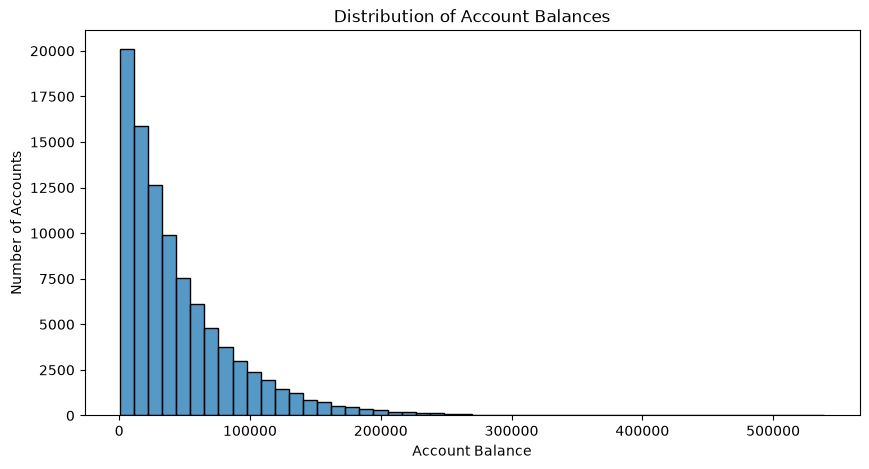

In [62]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="balance", bins=50)

plt.title("Distribution of Account Balances")
plt.xlabel("Account Balance")
plt.ylabel("Number of Accounts")

plt.show() 

## 5. Data Cleaning and Transformation

The `open_date` column is currently stored as text. It will be
converted to a datetime format to support reliable time-based
analysis.

In [63]:
df["open_date"] = pd.to_datetime(df["open_date"], errors="coerce") 

In [64]:
df["open_date"].dtype 

dtype('<M8[us]')

In [65]:
df["open_date"].isna().sum() 

np.int64(0)

In [66]:
print("Earliest account opening date:", df["open_date"].min())
print("Latest account opening date:", df["open_date"].max())

Earliest account opening date: 2005-01-01 00:00:00
Latest account opening date: 2026-05-31 00:00:00


In [67]:
df["open_date"].describe() 

count                         95000
mean     2015-09-16 13:35:56.968421
min             2005-01-01 00:00:00
25%             2010-05-09 00:00:00
50%             2015-09-13 00:00:00
75%             2021-01-26 00:00:00
max             2026-05-31 00:00:00
Name: open_date, dtype: object

In [68]:
analysis_date = df["open_date"].max()

analysis_date

Timestamp('2026-05-31 00:00:00')

In [69]:
df["account_tenure_days"] = (
    analysis_date - df["open_date"]
).dt.days

In [70]:
df["account_tenure_years"] = (
    df["account_tenure_days"] / 365.25
).round(2) 

In [71]:
df["account_tenure_years"].describe() 

count   95,000.00
mean        10.70
std          6.18
min          0.00
25%          5.34
50%         10.71
75%         16.06
max         21.41
Name: account_tenure_years, dtype: float64

In [72]:
df.groupby("status")["account_tenure_years"].describe() 

,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
Active,"80,707.00",10.69,6.18,0.00,5.33,10.70,16.05,21.41
Closed,"4,767.00",10.73,6.18,0.00,5.41,10.81,16.12,21.40
Dormant,"9,526.00",10.79,6.18,0.00,5.39,10.81,16.14,21.41


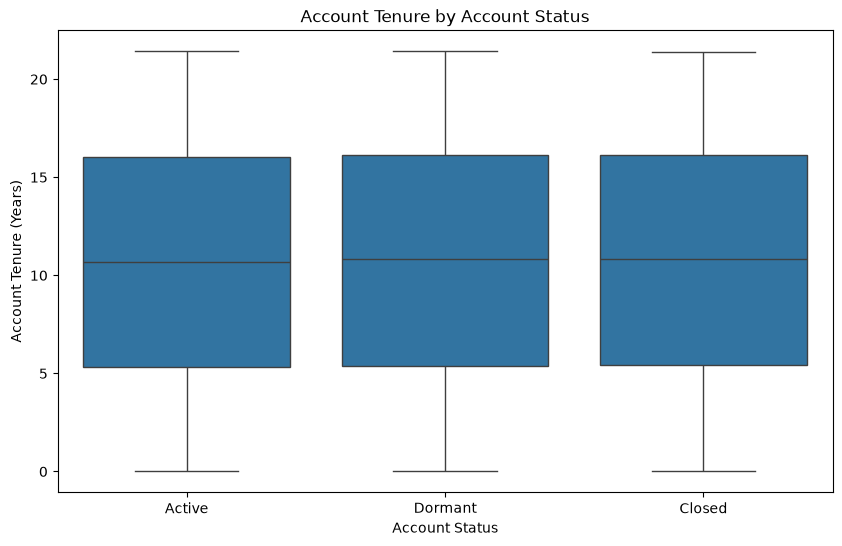

In [73]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="status",
    y="account_tenure_years"
)

plt.title("Account Tenure by Account Status")
plt.xlabel("Account Status")
plt.ylabel("Account Tenure (Years)")

plt.show() 

In [74]:
pd.crosstab(
    df["account_type"],
    df["status"]
)

status,Active,Closed,Dormant
account_type,,,
Current,16161,970,1890
Fixed Deposit,8054,445,959
NRI,3999,240,455
Salary,12066,722,1482
Savings,40427,2390,4740


In [75]:
status_by_type = pd.crosstab(
    df["account_type"],
    df["status"],
    normalize="index"
).mul(100).round(2)

status_by_type

status,Active,Closed,Dormant
account_type,,,
Current,84.96,5.10,9.94
Fixed Deposit,85.16,4.71,10.14
NRI,85.19,5.11,9.69
Salary,84.56,5.06,10.39
Savings,85.01,5.03,9.97


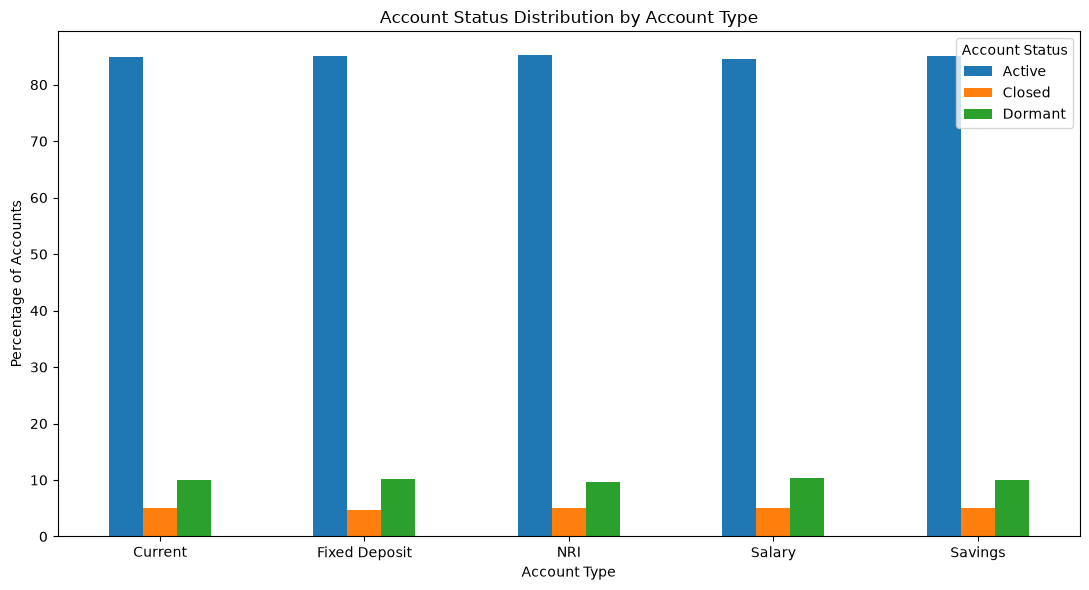

In [76]:
status_by_type.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Account Status Distribution by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Percentage of Accounts")
plt.xticks(rotation=0)
plt.legend(title="Account Status")
plt.tight_layout()

plt.show()

In [77]:
print("Number of unique customers:", df["customer_id"].nunique())
print("Number of unique branches:", df["branch_id"].nunique())

Number of unique customers: 47640
Number of unique branches: 150


In [78]:
print("Invalid dates after conversion:", df["open_date"].isna().sum())
print("Earliest date:", df["open_date"].min())
print("Latest date:", df["open_date"].max())

Invalid dates after conversion: 0
Earliest date: 2005-01-01 00:00:00
Latest date: 2026-05-31 00:00:00


In [82]:
df["balance"].describe() 

count    95,000.00
mean     45,761.24
std      45,306.41
min         500.36
25%      13,551.05
50%      31,768.65
75%      63,337.51
max     539,198.59
Name: balance, dtype: float64

In [83]:
print("Zero or negative balances:", (df["balance"] <= 0).sum())
print("Negative balances:", (df["balance"] < 0).sum())
print("Zero balances:", (df["balance"] == 0).sum()) 

Zero or negative balances: 0
Negative balances: 0
Zero balances: 0


In [84]:
balance_by_status = (
    df.groupby("status")["balance"]
      .agg(["count", "mean", "median", "min", "max", "std"])
      .round(2)
)

balance_by_status

,count,mean,median,min,max,std
status,,,,,,
Active,80707,"45,734.40","31,752.24",500.36,"539,198.59","45,237.55"
Closed,4767,"45,794.13","31,567.47",513.47,"467,517.73","46,172.43"
Dormant,9526,"45,972.11","31,981.88",500.49,"504,030.72","45,455.92"


In [85]:
df.groupby("status")["balance"].quantile(
    [0.25, 0.50, 0.75]
).unstack().round(2) 

,0.25,0.50,0.75
status,,,
Active,"13,521.59","31,752.24","63,445.77"
Closed,"13,340.90","31,567.47","62,532.88"
Dormant,"13,893.24","31,981.88","63,206.26"


In [86]:
df["balance"].quantile([0.25, 0.50, 0.75, 0.90, 0.95])

0.25    13,551.05
0.50    31,768.65
0.75    63,337.51
0.90   105,120.18
0.95   135,543.61
Name: balance, dtype: float64

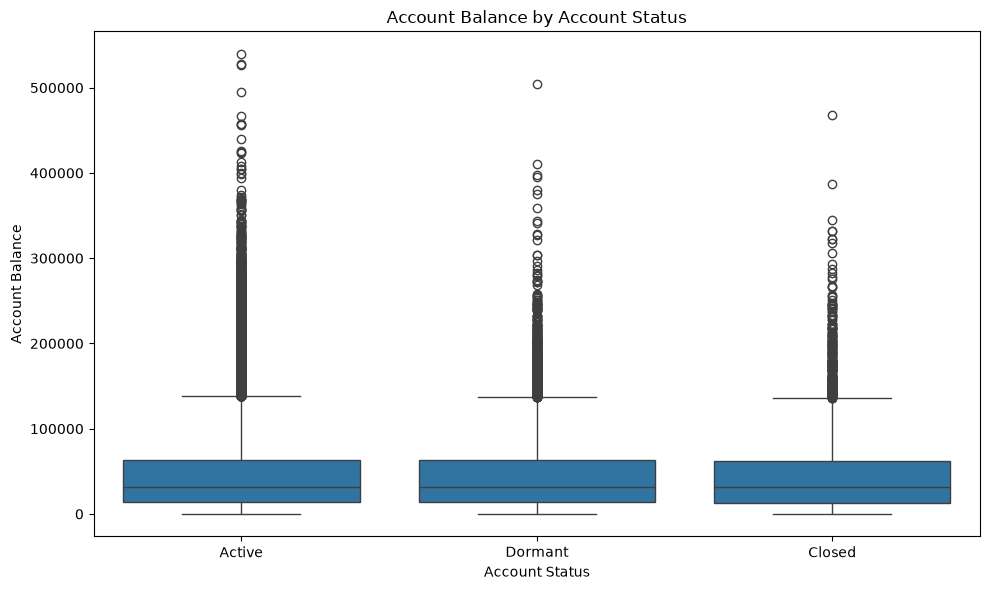

In [88]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="status",
    y="balance"
)

plt.title("Account Balance by Account Status")
plt.xlabel("Account Status")
plt.ylabel("Account Balance")

plt.tight_layout()
plt.show()

In [89]:
accounts_per_customer = (
    df.groupby("customer_id")["account_id"]
      .nunique()
)

In [90]:
accounts_per_customer.describe()

count   47,640.00
mean         1.99
std          1.08
min          1.00
25%          1.00
50%          2.00
75%          3.00
max          9.00
Name: account_id, dtype: float64

In [91]:
accounts_per_customer.value_counts().sort_index() 

account_id
1    19468
2    15370
3     8182
4     3236
5     1076
6      245
7       53
8        9
9        1
Name: count, dtype: int64

In [92]:
print(
    "Customers with multiple accounts:",
    (accounts_per_customer > 1).sum()
)

print(
    "Percentage of customers with multiple accounts:",
    round((accounts_per_customer > 1).mean() * 100, 2)
)

Customers with multiple accounts: 28172
Percentage of customers with multiple accounts: 59.14


In [93]:
accounts_per_customer[
    accounts_per_customer == accounts_per_customer.max()
]

customer_id
12265    9
Name: account_id, dtype: int64

In [95]:
customer_status = pd.crosstab(
    df["customer_id"],
    df["status"]
)

customer_status.head()

status,Active,Closed,Dormant
customer_id,,,
1,2,0,0
2,1,0,0
3,1,1,0
4,1,0,0
5,2,0,0


In [96]:
customer_status["Inactive"] = (
    customer_status.get("Dormant", 0) +
    customer_status.get("Closed", 0)
)

In [97]:
customer_status["has_active_account"] = (
    customer_status.get("Active", 0) > 0
)

customer_status["has_inactive_account"] = (
    customer_status["Inactive"] > 0
)

In [98]:
mixed_status_customers = customer_status[
    customer_status["has_active_account"] &
    customer_status["has_inactive_account"]
]

In [99]:
print(
    "Customers with both active and inactive accounts:",
    len(mixed_status_customers)
)

Customers with both active and inactive accounts: 9478


In [100]:
print(
    "Percentage:",
    round(
        len(mixed_status_customers) /
        len(customer_status) * 100,
        2
    )
)

Percentage: 19.9


In [102]:
customer_status["status_profile"] = np.select(
    [
        (customer_status["Active"] > 0) &
        (customer_status["Inactive"] == 0),

        (customer_status["Active"] == 0) &
        (customer_status["Inactive"] > 0),

        (customer_status["Active"] > 0) &
        (customer_status["Inactive"] > 0)
    ],
    [
        "Active only",
        "Inactive only",
        "Mixed status"
    ],
    default="Other"
)

In [103]:
customer_status["status_profile"].value_counts(
    normalize=True
).mul(100).round(2)

status_profile
Active only     73.26
Mixed status    19.90
Inactive only    6.85
Name: proportion, dtype: float64

In [106]:
balance_summary = df.groupby("status")["balance"].agg(
    accounts="count",
    mean="mean",
    median="median",
    min="min",
    max="max",
    std="std"
).round(2)

balance_summary

,accounts,mean,median,min,max,std
status,,,,,,
Active,80707,"45,734.40","31,752.24",500.36,"539,198.59","45,237.55"
Closed,4767,"45,794.13","31,567.47",513.47,"467,517.73","46,172.43"
Dormant,9526,"45,972.11","31,981.88",500.49,"504,030.72","45,455.92"


In [107]:
balance_percentiles = df.groupby("status")["balance"].quantile(
    [0.25, 0.50, 0.75, 0.90]
).unstack().round(2)

balance_percentiles

,0.25,0.50,0.75,0.90
status,,,,
Active,"13,521.59","31,752.24","63,445.77","105,055.65"
Closed,"13,340.90","31,567.47","62,532.88","104,937.84"
Dormant,"13,893.24","31,981.88","63,206.26","105,707.20"


In [108]:
customer_analysis = df.groupby("customer_id").agg(
    account_count=("account_id", "nunique"),
    total_balance=("balance", "sum"),
    average_balance=("balance", "mean")
)

customer_analysis.describe().round(2)

,account_count,total_balance,average_balance
count,"47,640.00","47,640.00","47,640.00"
mean,1.99,"91,253.52","45,743.55"
std,1.08,"81,089.71","36,774.59"
min,1.00,500.74,500.74
25%,1.00,"30,503.04","20,241.86"
50%,2.00,"69,462.14","37,340.64"
75%,3.00,"128,523.28","61,075.32"
max,9.00,"709,888.78","526,762.08"


In [109]:
customer_status = pd.crosstab(df["customer_id"], df["status"])

customer_status["inactive_accounts"] = (
    customer_status.get("Dormant", 0) +
    customer_status.get("Closed", 0)
)

customer_status["status_profile"] = np.select(
    [
        (customer_status.get("Active", 0) > 0) &
        (customer_status["inactive_accounts"] == 0),

        (customer_status.get("Active", 0) == 0) &
        (customer_status["inactive_accounts"] > 0),

        (customer_status.get("Active", 0) > 0) &
        (customer_status["inactive_accounts"] > 0)
    ],
    [
        "Active only",
        "Inactive only",
        "Mixed status"
    ],
    default="Other"
)

customer_status["status_profile"].value_counts()

status_profile
Active only      34899
Mixed status      9478
Inactive only     3263
Name: count, dtype: int64

In [110]:
customer_analysis = customer_analysis.join(
    customer_status["status_profile"]
)

customer_analysis.groupby("status_profile")[
    ["account_count", "total_balance", "average_balance"]
].agg(
    ["count", "mean", "median"]
).round(2)

account_count             total_balance                        \
                       count mean median         count       mean     median   
status_profile                                                                 
Active only            34899 1.82   2.00         34899  83,364.64  62,305.98   
Inactive only           3263 1.12   1.00          3263  51,196.53  34,536.91   
Mixed status            9478 2.93   3.00          9478 134,091.65 114,592.96   

               average_balance                      
                         count      mean    median  
status_profile                                      
Active only              34899 45,692.97 36,762.88  
Inactive only             3263 45,788.16 32,068.37  
Mixed status              9478 45,914.44 40,271.39

In [111]:
balance_summary = df.groupby("status")["balance"].agg(
    accounts="count",
    mean="mean",
    median="median",
    min="min",
    max="max"
).round(2)

balance_summary

,accounts,mean,median,min,max
status,,,,,
Active,80707,"45,734.40","31,752.24",500.36,"539,198.59"
Closed,4767,"45,794.13","31,567.47",513.47,"467,517.73"
Dormant,9526,"45,972.11","31,981.88",500.49,"504,030.72"


In [112]:
df.groupby("status")["balance"].quantile(
    [0.25, 0.50, 0.75, 0.90]
).unstack().round(2)

,0.25,0.50,0.75,0.90
status,,,,
Active,"13,521.59","31,752.24","63,445.77","105,055.65"
Closed,"13,340.90","31,567.47","62,532.88","104,937.84"
Dormant,"13,893.24","31,981.88","63,206.26","105,707.20"


In [113]:
branch_status = pd.crosstab(
    df["branch_id"],
    df["status"]
)

branch_status["total_accounts"] = branch_status.sum(axis=1)

branch_status["inactive_rate"] = (
    (branch_status.get("Dormant", 0) + branch_status.get("Closed", 0))
    / branch_status["total_accounts"] * 100
).round(2)

branch_status.sort_values(
    "inactive_rate",
    ascending=False
).head(10)

status,Active,Closed,Dormant,total_accounts,inactive_rate
branch_id,,,,,
23,493,42,82,617,20.10
131,486,32,86,604,19.54
9,519,38,78,635,18.27
53,506,27,85,618,18.12
111,521,32,82,635,17.95
106,516,31,81,628,17.83
83,527,36,78,641,17.78
112,505,37,72,614,17.75
60,517,46,65,628,17.68


In [114]:
branch_status.sort_values(
    "total_accounts",
    ascending=False
).head(10)

status,Active,Closed,Dormant,total_accounts,inactive_rate
branch_id,,,,,
132,603,31,66,700,13.86
58,600,32,68,700,14.29
15,599,31,52,682,12.17
150,578,33,64,675,14.37
66,576,35,63,674,14.54
77,572,35,67,674,15.13
29,557,40,73,670,16.87
50,569,27,73,669,14.95
91,566,33,70,669,15.40


In [115]:
branch_summary = branch_status[
    ["total_accounts", "inactive_rate"]
].describe().round(2)

branch_summary

status,total_accounts,inactive_rate
count,150.00,150.00
mean,633.33,15.05
std,23.81,1.55
min,570.00,11.21
25%,617.00,14.05
50%,634.00,14.95
75%,649.00,16.04
max,700.00,20.10


In [116]:
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(
    pd.crosstab(df["branch_id"], df["status"])
)

print("Chi-square statistic:", round(chi2, 2))
print("Degrees of freedom:", dof)
print("p-value:", p_value)

Chi-square statistic: 338.84
Degrees of freedom: 298
p-value: 0.05165505500161497


In [117]:
import numpy as np

n = pd.crosstab(
    df["branch_id"],
    df["status"]
).to_numpy().sum()

r, k = pd.crosstab(
    df["branch_id"],
    df["status"]
).shape

cramers_v = np.sqrt(
    (chi2 / n) / min(k - 1, r - 1)
)

print("Cramér's V:", round(cramers_v, 4))

Cramér's V: 0.0422


In [118]:
account_type_table = pd.crosstab(
    df["account_type"],
    df["status"]
)

chi2_type, p_type, dof_type, expected_type = chi2_contingency(
    account_type_table
)

print("Chi-square statistic:", round(chi2_type, 2))
print("Degrees of freedom:", dof_type)
print("p-value:", p_type) 

Chi-square statistic: 5.39
Degrees of freedom: 8
p-value: 0.7147337119247661


In [119]:
from scipy.stats import kruskal
balance_groups = [
    group["balance"].values
    for _, group in df.groupby("status")
]

h_stat, p_balance = kruskal(*balance_groups)

print("Kruskal-Wallis H:", round(h_stat, 2))
print("p-value:", p_balance)

Kruskal-Wallis H: 0.62
p-value: 0.7319864663837891


In [120]:
tenure_groups = [
    group["account_tenure_years"].values
    for _, group in df.groupby("status")
]

h_tenure, p_tenure = kruskal(*tenure_groups)

print("Kruskal-Wallis H:", round(h_tenure, 2))
print("p-value:", p_tenure)

Kruskal-Wallis H: 2.19
p-value: 0.3338044617030517


In [121]:
statistical_results = pd.DataFrame({
    "Analysis": [
        "Branch vs Status",
        "Account Type vs Status",
        "Balance vs Status",
        "Tenure vs Status"
    ],
    "Test": [
        "Chi-square",
        "Chi-square",
        "Kruskal-Wallis",
        "Kruskal-Wallis"
    ],
    "Statistic": [
        chi2,
        chi2_type,
        h_stat,
        h_tenure
    ],
    "p_value": [
        p_value,
        p_type,
        p_balance,
        p_tenure
    ]
})

statistical_results.round(4)

,Analysis,Test,Statistic,p_value
0,Branch vs Status,Chi-square,338.84,0.05
1,Account Type vs Status,Chi-square,5.39,0.71
2,Balance vs Status,Kruskal-Wallis,0.62,0.73
3,Tenure vs Status,Kruskal-Wallis,2.19,0.33


In [122]:
print(f"Branch p-value: {p_value:.10f}")
print(f"Branch Cramér's V: {cramers_v:.6f}")

Branch p-value: 0.0516550550
Branch Cramér's V: 0.042230


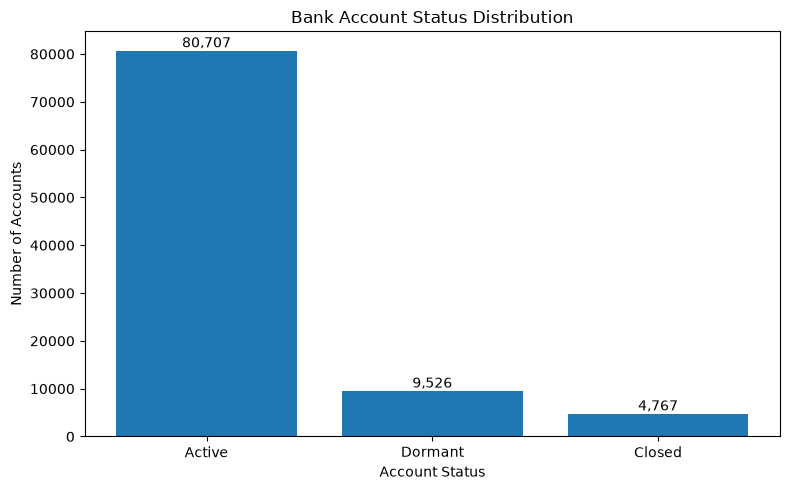

In [123]:
# Account status distribution

status_counts = df["status"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(status_counts.index, status_counts.values)

plt.title("Bank Account Status Distribution")
plt.xlabel("Account Status")
plt.ylabel("Number of Accounts")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

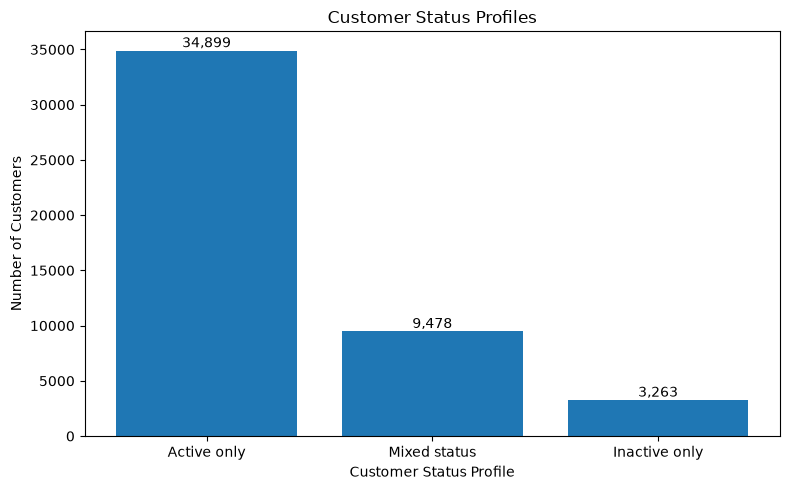

In [124]:
# Customer status profile distribution

profile_counts = customer_status["status_profile"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(profile_counts.index, profile_counts.values)

plt.title("Customer Status Profiles")
plt.xlabel("Customer Status Profile")
plt.ylabel("Number of Customers")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

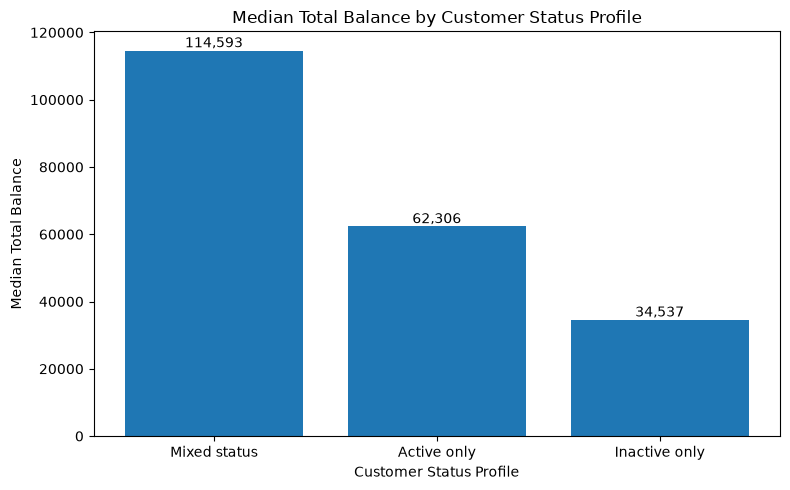

In [125]:
# Median total balance by customer status profile

median_balance = (
    customer_analysis
    .groupby("status_profile")["total_balance"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
bars = plt.bar(median_balance.index, median_balance.values)

plt.title("Median Total Balance by Customer Status Profile")
plt.xlabel("Customer Status Profile")
plt.ylabel("Median Total Balance")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

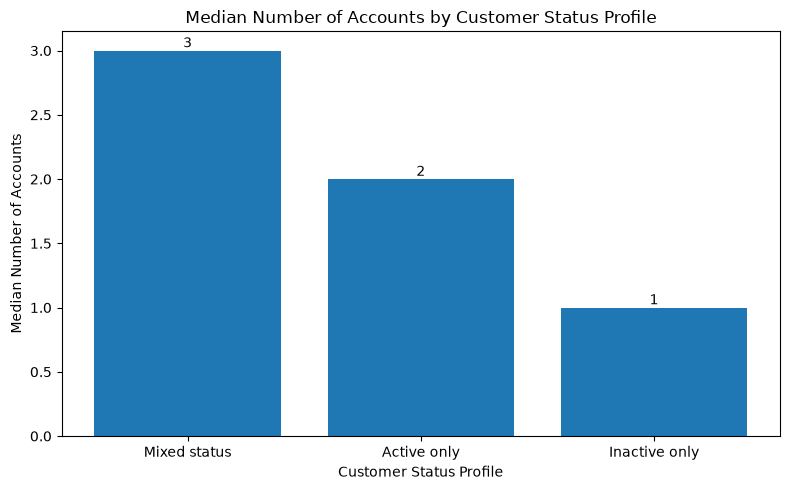

In [126]:
# Median number of accounts by customer status profile

median_accounts = (
    customer_analysis
    .groupby("status_profile")["account_count"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
bars = plt.bar(median_accounts.index, median_accounts.values)

plt.title("Median Number of Accounts by Customer Status Profile")
plt.xlabel("Customer Status Profile")
plt.ylabel("Median Number of Accounts")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [127]:
findings = pd.DataFrame({
    "Finding": [
        "Most accounts are active",
        "Dormant and closed accounts form a smaller but important segment",
        "Mixed-status customers have more accounts",
        "Mixed-status customers have higher total balances",
        "Branch and account-level factors show limited statistical evidence of association"
    ],
    
    "Evidence": [
        "80,707 accounts (84.95%) are active",
        "14,293 accounts (15.05%) are dormant or closed",
        "Median of 3 accounts per mixed-status customer",
        "Median total balance = 114,592.96",
        "Statistical tests produced p-values above 0.05"
    ],
    
    "Business_Relevance": [
        "The majority of the bank's accounts remain active",
        "This segment can be examined to understand inactivity and closure patterns",
        "Customers with multiple accounts may require separate behavioral analysis",
        "Mixed-status customers represent a relatively high-balance customer segment",
        "The available evidence does not establish strong relationships for these factors"
    ]
})

findings

,Finding,Evidence,Business_Relevance
0,Most accounts are active,"80,707 accounts (84.95%) are active",The majority of the bank's accounts remain active
1,Dormant and closed accounts form a smaller but...,"14,293 accounts (15.05%) are dormant or closed",This segment can be examined to understand ina...
2,Mixed-status customers have more accounts,Median of 3 accounts per mixed-status customer,Customers with multiple accounts may require s...
3,Mixed-status customers have higher total balances,"Median total balance = 114,592.96",Mixed-status customers represent a relatively ...
4,Branch and account-level factors show limited ...,Statistical tests produced p-values above 0.05,The available evidence does not establish stro...


In [128]:
statistical_findings = pd.DataFrame({
    "Analysis": [
        "Branch vs Status",
        "Account Type vs Status",
        "Balance vs Status",
        "Tenure vs Status"
    ],
    "Test": [
        "Chi-square",
        "Chi-square",
        "Kruskal-Wallis",
        "Kruskal-Wallis"
    ],
    "Statistic": [
        338.84,
        5.39,
        0.62,
        2.19
    ],
    "P_Value": [
        0.05,
        0.71,
        0.73,
        0.33
    ]
})

statistical_findings

,Analysis,Test,Statistic,P_Value
0,Branch vs Status,Chi-square,338.84,0.05
1,Account Type vs Status,Chi-square,5.39,0.71
2,Balance vs Status,Kruskal-Wallis,0.62,0.73
3,Tenure vs Status,Kruskal-Wallis,2.19,0.33


## Key Findings

1. **Account inactivity:** 15.05% of accounts are either dormant or closed, indicating a meaningful inactive-account segment.

2. **Customer status profiles:** 19.90% of customers have mixed account statuses, meaning they hold accounts with different activity states.

3. **Mixed-status customers:** Customers with mixed account statuses have the highest median account count and median total balance among the three customer profiles.

4. **Balance:** Account balances do not show statistically significant differences across active, dormant, and closed accounts (Kruskal-Wallis, p = 0.73).

5. **Account tenure:** No statistically significant difference in account tenure was detected across account-status groups (Kruskal-Wallis, p = 0.33).

6. **Account type:** No statistically significant association was detected between account type and account status (Chi-square, p = 0.71).

7. **Branch:** The branch-status relationship produced a borderline statistical result and requires further investigation before drawing a strong conclusion.